In [1]:
# ==============================================================================
# BITÁCORA V2: AJUSTES AL PROTOTIPO Y ANÁLISIS ESTADÍSTICO
# Autores: Alexis Vaca y Lizbeth Suárez
# Fecha: Marzo 2026
# Instalación de dependencias requeridas para el modelado
!pip install prophet holidays --quiet

# Importación de librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import holidays

# Montaje de la unidad de almacenamiento
drive.mount('/content/drive')

# Ingesta del dataset maestro unificado
ruta_maestra = '/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Master_Ventas_Unificado.csv'
df_maestro = pd.read_csv(ruta_maestra)
df_maestro['ds'] = pd.to_datetime(df_maestro['ds'])

print(f"Dataset maestro ingestado correctamente. Total de transacciones: {len(df_maestro)}")

Mounted at /content/drive
Dataset maestro ingestado correctamente. Total de transacciones: 31778


In [2]:
# Ingeniería de Características (Feature Engineering)

# 1. Construcción de regresor continuo: Precio Promedio Unitario
df_maestro['precio_unitario'] = df_maestro['total'] / df_maestro['cantidad']

# Agrupación temporal (Resampling mensual)
df_mensual = df_maestro.set_index('ds').resample('MS').agg({
    'cantidad': 'sum',
    'precio_unitario': 'mean'
}).reset_index()

# Renombramiento de variables bajo el estándar de Prophet
df_mensual.columns = ['ds', 'y', 'precio']

# 2. Construcción de regresor categórico: Calendario de Feriados (Ecuador)
feriados_ec = holidays.EC(years=range(2018, 2025))

feriados_df = pd.DataFrame([
    {'holiday': 'feriado_ecuador', 'ds': fecha, 'lower_window': 0, 'upper_window': 1}
    for fecha in feriados_ec.keys()
])

print("Feature Engineering completado con éxito:")
print(f"- Longitud de la serie temporal: {len(df_mensual)} meses.")
print(f"- Total de eventos exógenos (feriados) mapeados: {len(feriados_df)}")
display(df_mensual.head())

Feature Engineering completado con éxito:
- Longitud de la serie temporal: 84 meses.
- Total de eventos exógenos (feriados) mapeados: 106


,ds,y,precio
0,2018-01-01,231893.2,43.414837
1,2018-02-01,147383.0,31.255103
2,2018-03-01,224041.8,38.561304
3,2018-04-01,208936.0,27.059327
4,2018-05-01,243589.4,28.148846


In [3]:
# ==============================================================================
# SECCIÓN 2: AJUSTE DEL MODELO Y ENTRENAMIENTO MULTIVARIANTE
# ==============================================================================
from prophet import Prophet

# 1. Instanciación del modelo con hiperparámetros optimizados
modelo_ajustado = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,    # Ajuste de flexibilidad de tendencia
    seasonality_prior_scale=10.0,   # Ajuste de susceptibilidad estacional
    holidays=feriados_df            # Integración de regresor categórico
)

# 2. Integración de regresor continuo (Variables Exógenas)
modelo_ajustado.add_regressor('precio')

# 3. Ajuste del modelo (Training)
print("Entrenando modelo Prophet ajustado...")
modelo_ajustado.fit(df_mensual)
print("Modelo entrenado exitosamente con regresores exógenos.")

Entrenando modelo Prophet ajustado...
Modelo entrenado exitosamente con regresores exógenos.


In [4]:
# ==============================================================================
# SECCIÓN 3: VALIDACIÓN ESTADÍSTICA (TIME SERIES CROSS-VALIDATION)
# ==============================================================================
from prophet.diagnostics import cross_validation, performance_metrics
import logging

# Supresión de warnings de Prophet para limpieza de consola
logging.getLogger('prophet').setLevel(logging.WARNING)

print("Iniciando Validación Cruzada (Rolling Forecast)...")
print("Configuración: Entrenamiento inicial = 3 años, Periodo = 180 días, Horizonte = 90 días.")

# 1. Ejecución de Cross-Validation
# initial: Usar al menos 3 años para aprender (1095 días)
# period: Mover la ventana cada 6 meses (180 días)
# horizon: Predecir 3 meses hacia el futuro (90 días)
df_cv = cross_validation(modelo_ajustado, initial='1095 days', period='180 days', horizon='90 days')

# 2. Cálculo de métricas de rendimiento por cada horizonte
df_p = performance_metrics(df_cv)

# 3. Extracción de estadísticos clave para reporte
rmse_promedio = df_p['rmse'].mean()
rmse_std = df_p['rmse'].std()
mae_promedio = df_p['mae'].mean()

print("\n" + "="*50)
print("📊 REPORTE DE ANÁLISIS ESTADÍSTICO")
print("="*50)
print(f"Métrica RMSE Promedio:         {rmse_promedio:.2f} Kg")
print(f"Desviación Estándar (Sigma):   {rmse_std:.2f} Kg")
print(f"Métrica MAE Promedio:          {mae_promedio:.2f} Kg")
print("="*50)
print("Nota: Un Sigma bajo indica alta estabilidad y baja variabilidad en las predicciones.")

Iniciando Validación Cruzada (Rolling Forecast)...
Configuración: Entrenamiento inicial = 3 años, Periodo = 180 días, Horizonte = 90 días.


  0%|          | 0/8 [00:00<?, ?it/s]


📊 REPORTE DE ANÁLISIS ESTADÍSTICO
Métrica RMSE Promedio:         38302.22 Kg
Desviación Estándar (Sigma):   24215.78 Kg
Métrica MAE Promedio:          34785.35 Kg
Nota: Un Sigma bajo indica alta estabilidad y baja variabilidad en las predicciones.


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


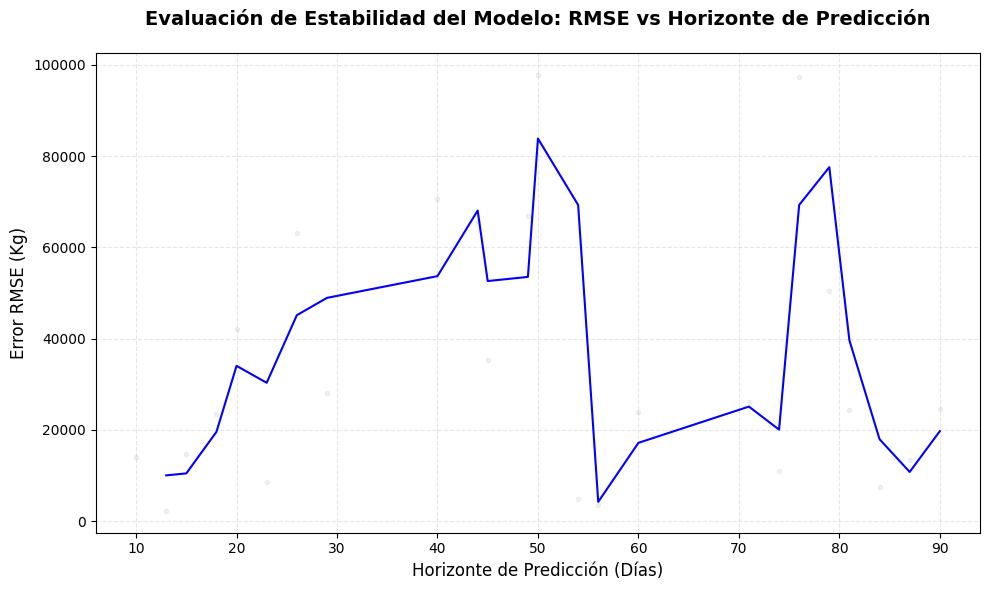

In [5]:
# Generación de visualización de métricas de Validación Cruzada
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

# Creación de la figura evaluando el RMSE a lo largo del horizonte de predicción
fig = plot_cross_validation_metric(df_cv, metric='rmse')

# Configuración de diseño profesional para el reporte
plt.title('Evaluación de Estabilidad del Modelo: RMSE vs Horizonte de Predicción', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Error RMSE (Kg)', fontsize=12)
plt.xlabel('Horizonte de Predicción (Días)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Despliegue de la gráfica
plt.tight_layout()
plt.show()